Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Exercise04

This last exercise is an opportunity for you to get started on your final project. Please identify a portion of your project to get started on and submit a notebook (and any other related files) where you:

1. State the question you are aiming to address with this portion of your analysis
2. Outline the approach you will use to answer that question (pseudocode or you can start to more formally outline the approach section for your final narrative)
3. Operationalize your approach with data and code that you can later slot into your final analysis

## Submitting

Please make a pull request with all of your code and reasonably-sized data in a folder named with your first name. See my example file structure in the `exercise04` directory:

```
exercises
└── exercise04
    └── chester
        ├── example_ReadMe.md
        ├── exercise04_chester.ipynb
        ├── example_module.py
        └── example_data.csv
```

If you have datasets that are too large for GitHub or should not be made public, please upload them to the [Google Drive folder for final project data](https://drive.google.com/drive/folders/1jgLIxx1B67nD4PekfDJnUI5jmrqa4iZm). Please also provide instructions for how someone running your code should properly locate or connect to these files so the analysis will run properly. For example, should they copy and paste the files into the same directory as your notebook, or a provided `data` directory? Best practice is to include these instructions in a separate ReadMe.md or ReadMe.txt file, or at the top of your notebook.

Main research question: 

Is housing cost burden associated with crime rate across census tracts in Prince George's County?

Approach:
1. Use ACS data to measure housing burden (30%+, 50%+)
2. Use crime incident data to calculate crime rates per 1,000 people
3. Spatially join crime data to census tracts
4. Compare crime rates across tracts with different levels of housing burden

Data preparation:

In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
acs = pd.read_excel("ACSDTY2024_tract.xlsx")

In [6]:
crime = pd.read_excel("PG_Crime_Incidents_2024.xlsx")

In [7]:
tracts = gpd.read_file("tl_2024_24_tract/tl_2024_24_tract.shp")

Crime data processing:

In [8]:
crime.columns

Index(['Incident Case Id', 'Date', 'Clearance Code Inc Type',
       'PGPD Reporting Area', 'PGPD Sector', 'PGPD BEAT', 'Street Number',
       'Street Name', 'Latitude', 'Longitude', 'Location'],
      dtype='str')

In [9]:
crime["Clearance Code Inc Type"].unique()

<ArrowStringArray>
[                 'ASSAULT',                 'ACCIDENT',
    'ACCIDENT WITH IMPOUND',             'AUTO, STOLEN',
        'ASSAULT, SHOOTING',        'B & E, COMMERCIAL',
          'ASSAULT, WEAPON',          'THEFT FROM AUTO',
                    'THEFT',       'B & E, RESIDENTIAL',
                 'HOMICIDE',              'SEX OFFENSE',
         'ROBBERY, VEHICLE', 'AUTO, STOLEN & RECOVERED',
           'ROBBERY, OTHER',     'ROBBERY, RESIDENTIAL',
             'B & E, OTHER',      'ROBBERY, COMMERCIAL']
Length: 18, dtype: str

In [10]:
mapping = {
    # violent
    "ASSAULT": "violent",
    "ASSAULT, SHOOTING": "violent",
    "ASSAULT, WEAPON": "violent",
    "HOMICIDE": "violent",
    "ROBBERY, COMMERCIAL": "violent",
    "ROBBERY, OTHER": "violent",
    "ROBBERY, RESIDENTIAL": "violent",
    "ROBBERY, VEHICLE": "violent",
    "SEX OFFENSE": "violent",

    # property
    "AUTO, STOLEN": "property",
    "AUTO, STOLEN & RECOVERED": "property",
    "B & E, COMMERCIAL": "property",
    "B & E, OTHER": "property",
    "B & E, RESIDENTIAL": "property",
    "THEFT": "property",
    "THEFT FROM AUTO": "property"
}

In [11]:
crime["crime_category"] = crime["Clearance Code Inc Type"].map(mapping)

In [12]:
crime = crime[~crime["Clearance Code Inc Type"].str.contains("ACCIDENT")]

In [13]:
crime["crime_category"].isna().sum()

np.int64(0)

Spatial Join:

In [14]:
from shapely.geometry import Point

crime_gdf = gpd.GeoDataFrame(
    crime,
    geometry=gpd.points_from_xy(crime["Longitude"], crime["Latitude"]),
    crs="EPSG:4326"
)

In [15]:
crime_gdf = crime_gdf.to_crs(tracts.crs)

In [16]:
crime_tract = gpd.sjoin(
    crime_gdf,
    tracts,
    how="left",
    predicate="within"
)

In [17]:
crime_tract.head()

,Incident Case Id,Date,Clearance Code Inc Type,PGPD Reporting Area,PGPD Sector,PGPD BEAT,Street Number,Street Name,Latitude,Longitude,...,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
0,PP24010100000090,2024-01-01,ASSAULT,517,J,J3,900 BLOCK,MARCY AVE,38.817105,-76.993919,...,24033801707,1400000US24033801707,8017.07,Census Tract 8017.07,G5020,S,2089822.0,0.0,+38.8130945,-076.9848028
3,PP24010100000342,2024-01-01,ASSAULT,827,D,D2,9800 BLOCK,GOOD LUCK RD EB,38.989677,-76.836111,...,24033800412,1400000US24033800412,8004.12,Census Tract 8004.12,G5020,S,2178862.0,0.0,+38.9839494,-076.8433498
4,PP24010100000383,2024-01-01,"AUTO, STOLEN",842,D,D6,9000 BLOCK,91S PL,38.948995,-76.850547,...,24033803608,1400000US24033803608,8036.08,Census Tract 8036.08,G5020,S,5186094.0,45636.0,+38.9550751,-076.8506247
5,PP24010100000443,2024-01-01,"AUTO, STOLEN",244,B,B4,7000 BLOCK,GREENVALE PKWY,38.947683,-76.895822,...,24033803801,1400000US24033803801,8038.01,Census Tract 8038.01,G5020,S,1249305.0,0.0,+38.9457530,-076.9052779
8,PP24010100000482,2024-01-01,"ASSAULT, SHOOTING",234,B,B4,4700 BLOCK,66T PL,38.942761,-76.906321,...,24033803801,1400000US24033803801,8038.01,Census Tract 8038.01,G5020,S,1249305.0,0.0,+38.9457530,-076.9052779


In [18]:
crime_tract["GEOID"].isna().sum()

np.int64(36)

In [19]:
crime_total = crime_tract.groupby("GEOID").size().reset_index(name="crime_total")
crime_total.head()

,GEOID,crime_total
0,24031701425,1
1,24031701601,3
2,24031701704,5
3,24031702000,1
4,24033800105,15


In [20]:
crime_by_type = (
    crime_tract
    .groupby(["GEOID", "crime_category"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

crime_by_type.head()

crime_category,GEOID,property,violent
0,24031701425,0,1
1,24031701601,3,0
2,24031701704,5,0
3,24031702000,1,0
4,24033800105,13,2


In [21]:
acs.columns

Index(['GEO_ID', 'NAME', 'Total_population', 'Non_Hispanic_Other',
       'Non_Hispanic_White', 'Non_Hispanic_Black', 'Non_Hispanic_Asian',
       'Hispanic', 'Renter_not_cost_burdened', 'Renter_cost_burdened',
       'Renter_severely_cost_burdened', 'Renter_not_computed',
       'Owner_cost_burdened', 'Owner_severely_cost_burdened',
       'Owner_not_cost_burdened', 'Owner_not_computed', 'Total_households',
       'Owner', 'Renter', 'Median_household_income'],
      dtype='str')

In [22]:
acs["GEOID"] = acs["GEO_ID"].str[-11:]

Housing Burden Calculation:

In [23]:
acs["pct_renter_burden"] = (
    acs["Renter_cost_burdened"] + acs["Renter_severely_cost_burdened"]
) / acs["Renter"]

In [24]:
acs["pct_renter_burden"] = acs["pct_renter_burden"].fillna(0)

In [25]:
acs[["GEOID", "pct_renter_burden"]].head()

,GEOID,pct_renter_burden
0,24033800102,0.504722
1,24033800103,0.389549
2,24033800105,0.450980
3,24033800106,0.523256
4,24033800108,0.426619


In [26]:
df = crime_by_type.merge(acs, on="GEOID", how="left")

In [27]:
df[["GEOID", "property", "violent", "pct_renter_burden"]].head()

,GEOID,property,violent,pct_renter_burden
0,24031701425,0,1,NaN
1,24031701601,3,0,NaN
2,24031701704,5,0,NaN
3,24031702000,1,0,NaN
4,24033800105,13,2,0.45098


In [28]:
crime_pg = crime_tract[
    crime_tract["GEOID"].astype(str).str.startswith("24033")
].copy()

In [29]:
crime_by_type = (
    crime_pg
    .groupby(["GEOID", "crime_category"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

In [30]:
df = crime_by_type.merge(acs, on="GEOID", how="left")

In [31]:
df["pct_renter_burden"].isna().sum()

np.int64(0)

Crime rate calculation:

In [32]:
df["crime_total"] = df["property"] + df["violent"]

df["property_rate"] = df["property"] / df["Total_population"] * 1000
df["violent_rate"] = df["violent"] / df["Total_population"] * 1000
df["crime_rate"] = df["crime_total"] / df["Total_population"] * 1000

In [33]:
df["property_rate"] = df["property"] / df["Total_population"] * 1000
df["violent_rate"] = df["violent"] / df["Total_population"] * 1000

In [34]:
df["pct_renter_severe_burden"] = df["Renter_severely_cost_burdened"] / df["Renter"]

In [35]:
df["severe_group"] = df["pct_renter_severe_burden"].apply(
    lambda x: "high" if x > 0 else "low"
)

In [36]:
df.groupby("severe_group")["crime_rate"].mean()

severe_group
high    22.474015
low     12.901138
Name: crime_rate, dtype: float64

Mapping:

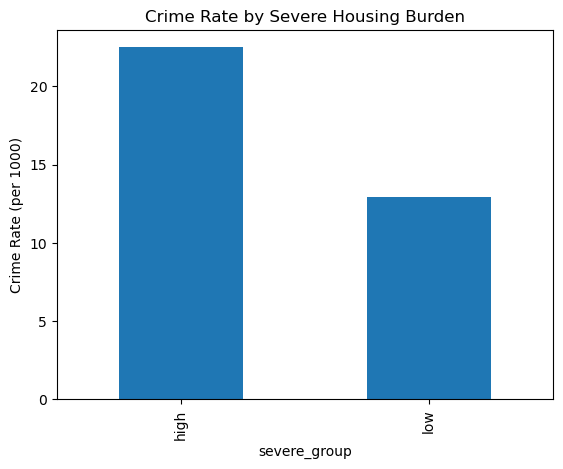

In [37]:
import matplotlib.pyplot as plt

group_mean = df.groupby("severe_group")["crime_rate"].mean()

group_mean.plot(kind="bar")
plt.ylabel("Crime Rate (per 1000)")
plt.title("Crime Rate by Severe Housing Burden")
plt.show()

In [38]:
map_df = tracts.merge(df, on="GEOID", how="left")

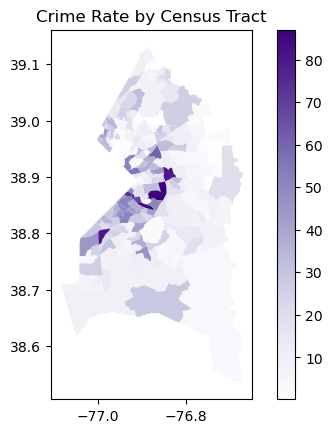

In [39]:
map_df.plot(column="crime_rate", cmap="Purples", legend=True)
plt.title("Crime Rate by Census Tract")
plt.show()

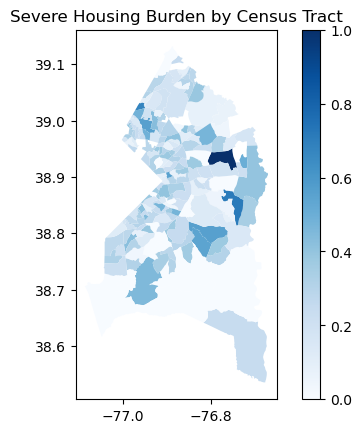

In [40]:
map_df.plot(column="pct_renter_severe_burden", cmap="Blues", legend=True)
plt.title("Severe Housing Burden by Census Tract")
plt.show()

In [41]:
df["pct_renter_burden_30plus"] = (
    df["Renter_cost_burdened"] + df["Renter_severely_cost_burdened"]
) / df["Renter"]

In [42]:
df["pct_renter_burden_30plus"] = df["pct_renter_burden_30plus"].fillna(0)

In [43]:
map_df = tracts.merge(df, on="GEOID", how="left")

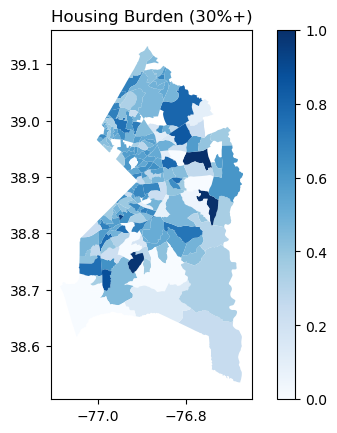

In [44]:
map_df.plot(column="pct_renter_burden_30plus", cmap="Blues", legend=True)
plt.title("Housing Burden (30%+)")
plt.show()